In [21]:
!pip install nltk scikit-learn

import pandas as pd
import numpy as np
import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [22]:
from google.colab import files
uploaded = files.upload()

Saving spam_ham_dataset.csv to spam_ham_dataset (1).csv


In [23]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [24]:
df.columns

Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')

In [25]:
df = df[['text', 'label']]

In [26]:
df.columns = ['email_text', 'label']
df.head()

,email_text,label
0,Subject: enron methanol ; meter # : 988291\r\n...,ham
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",ham
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",ham
3,"Subject: photoshop , windows , office . cheap ...",spam
4,Subject: re : indian springs\r\nthis deal is t...,ham


In [27]:
df['label'] = df['label'].map({'ham':0, 'spam':1})
df.head()

,email_text,label
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0


In [28]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

import re
import string

def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'\n', ' ', text)          # remove new lines
    text = re.sub(r'http\S+', '', text)      # remove links
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]

    return " ".join(words)

df['clean_email'] = df['email_text'].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,email_text,label,clean_email
0,Subject: enron methanol ; meter # : 988291\r\n...,0,subject enron methanol meter follow note gave ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,subject hpl nom january see attached file hpln...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,subject neon retreat ho ho ho around wonderful...
3,"Subject: photoshop , windows , office . cheap ...",1,subject photoshop windows office cheap main tr...
4,Subject: re : indian springs\r\nthis deal is t...,0,subject indian springs deal book teco pvr reve...


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
X = vectorizer.fit_transform(df['clean_email'])
y = df['label']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [32]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9420289855072463
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       742
           1       0.87      0.94      0.90       293

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg       0.94      0.94      0.94      1035



In [38]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[700  42]
 [ 18 275]]


In [33]:
def predict_email(email_text):
    cleaned = clean_text(email_text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)

    return "Spam" if prediction[0] == 1 else "Not Spam"

In [34]:
predict_email("Subject: WINNER!! You have won a free lottery. Click now to claim.")

'Spam'

In [35]:
predict_email("Subject: Meeting scheduled tomorrow at 10 AM. Please attend.")

'Not Spam'

In [36]:
predict_email("Subject: You won a lottery! Click now")

'Spam'

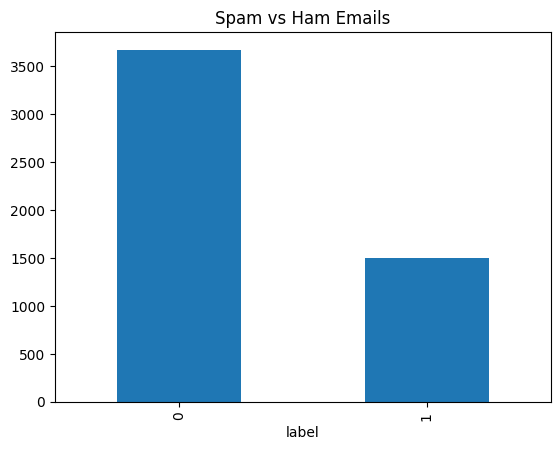

In [37]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Emails")
plt.show()

In [39]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

In [40]:
from google.colab import files
files.download('model.pkl')
files.download('vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>